In [32]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder


# **I. Loading the ViT embedded vectors**

In [33]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Giả sử: root_dir là folder chứa các class con
root_dir = "ViT-L14-embeddings-vectors/Train"  # đổi lại cho đúng

image_paths = []
labels = []

for class_name in os.listdir(root_dir):
    class_folder = os.path.join(root_dir, class_name)
    if not os.path.isdir(class_folder):
        continue
    
    for fname in os.listdir(class_folder):
        if not fname.lower().endswith((".npy")):
            continue
        
        img_path = os.path.join(class_folder, fname)
        
        image_paths.append(img_path)
        labels.append(class_name)  # label = tên folder

# Chuyển label dạng text -> số
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Tính embedding cho từng ảnh -> X
embeddings = []
for path in image_paths:
    vec = np.load(path)
    embeddings.append(vec)



In [34]:
X_train = np.vstack(embeddings)          # shape (num_samples, embedding_dim)
y_train = np.array(y)                  # shape (num_samples,)
print(X_train.shape, y_train.shape)


(17581, 768) (17581,)


In [35]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Giả sử: root_dir là folder chứa các class con
root_dir = "ViT-L14-embeddings-vectors/Test"  # đổi lại cho đúng

image_paths = []
labels = []

for class_name in os.listdir(root_dir):
    class_folder = os.path.join(root_dir, class_name)
    if not os.path.isdir(class_folder):
        continue
    
    for fname in os.listdir(class_folder):
        if not fname.lower().endswith((".npy")):
            continue
        
        img_path = os.path.join(class_folder, fname)
        
        image_paths.append(img_path)
        labels.append(class_name)  # label = tên folder

# Chuyển label dạng text -> số
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Tính embedding cho từng ảnh -> X
embeddings = []
for path in image_paths:
    vec = np.load(path)
    embeddings.append(vec)



In [36]:
X_test = np.vstack(embeddings)          # shape (num_samples, embedding_dim)
y_test = np.array(y)                  # shape (num_samples,)
print(X_test.shape, y_test.shape)


(5040, 768) (5040,)


In [37]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Giả sử: root_dir là folder chứa các class con
root_dir = "ViT-L14-embeddings-vectors/Validate"  # đổi lại cho đúng

image_paths = []
labels = []

for class_name in os.listdir(root_dir):
    class_folder = os.path.join(root_dir, class_name)
    if not os.path.isdir(class_folder):
        continue
    
    for fname in os.listdir(class_folder):
        if not fname.lower().endswith((".npy")):
            continue
        
        img_path = os.path.join(class_folder, fname)
        
        image_paths.append(img_path)
        labels.append(class_name)  # label = tên folder

# Chuyển label dạng text -> số
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Tính embedding cho từng ảnh -> X
embeddings = []
for path in image_paths:
    vec = np.load(path)
    embeddings.append(vec)



In [38]:
X_val = np.vstack(embeddings)          # shape (num_samples, embedding_dim)
y_val = np.array(y)                  # shape (num_samples,)
print(X_val.shape, y_val.shape)


(2515, 768) (2515,)


> **Concat Validate and Train datasets**

In [39]:
X_train = np.vstack((X_train, X_val))
y_train = np.concatenate((y_train, y_val))


In [ ]:
X_train.shape, y_train.shape


((20096, 768), (20096,))

# **II. GridSearchCV + Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Khởi tạo model cơ bản
rf = RandomForestClassifier(n_jobs=-1, random_state=42)

# 2. Tạo grid hyperparams
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, 40],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4]
}

# 3. Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="accuracy",  
    verbose=2,
    n_jobs=-1
)

# 4. Train GridSearchCV
grid_search.fit(X_train, y_train)

# 5. In kết quả tốt nhất
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 1.1min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 5.2min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 5.2min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 5.2min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 2.1min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 2.1min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time= 5.2min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estim

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,   # số cây, có thể tăng/giảm
    max_depth=20,    # để None cho cây thoải mái sâu, hoặc giới hạn lại nếu bị overfit
    n_jobs=-1,         # dùng tất cả CPU core
    random_state=42,
    min_samples_leaf=1,
    min_samples_split= 10
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=500,
                       n_jobs=-1, random_state=42)

In [43]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.8567460317460317
                  precision    recall  f1-score   support

        Banh beo       0.93      0.84      0.89       129
    Banh bot loc       0.90      0.73      0.80       144
        Banh can       0.90      0.81      0.85       149
       Banh canh       0.82      0.62      0.70       193
      Banh chung       0.82      0.82      0.82       102
       Banh cuon       0.80      0.87      0.83       228
        Banh duc       0.82      0.47      0.59       133
        Banh gio       0.84      0.89      0.86       129
       Banh khot       0.87      0.91      0.89       167
         Banh mi       0.96      0.98      0.97       268
        Banh pia       0.95      0.99      0.97        89
        Banh tet       0.81      0.83      0.82       138
Banh trang nuong       0.91      0.89      0.90       159
        Banh xeo       0.91      0.94      0.93       235
      Bun bo Hue       0.74      0.87      0.80       306
 Bun dau mam tom       0.90      0.99     

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np


In [13]:
cm = confusion_matrix(y_test, y_pred)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


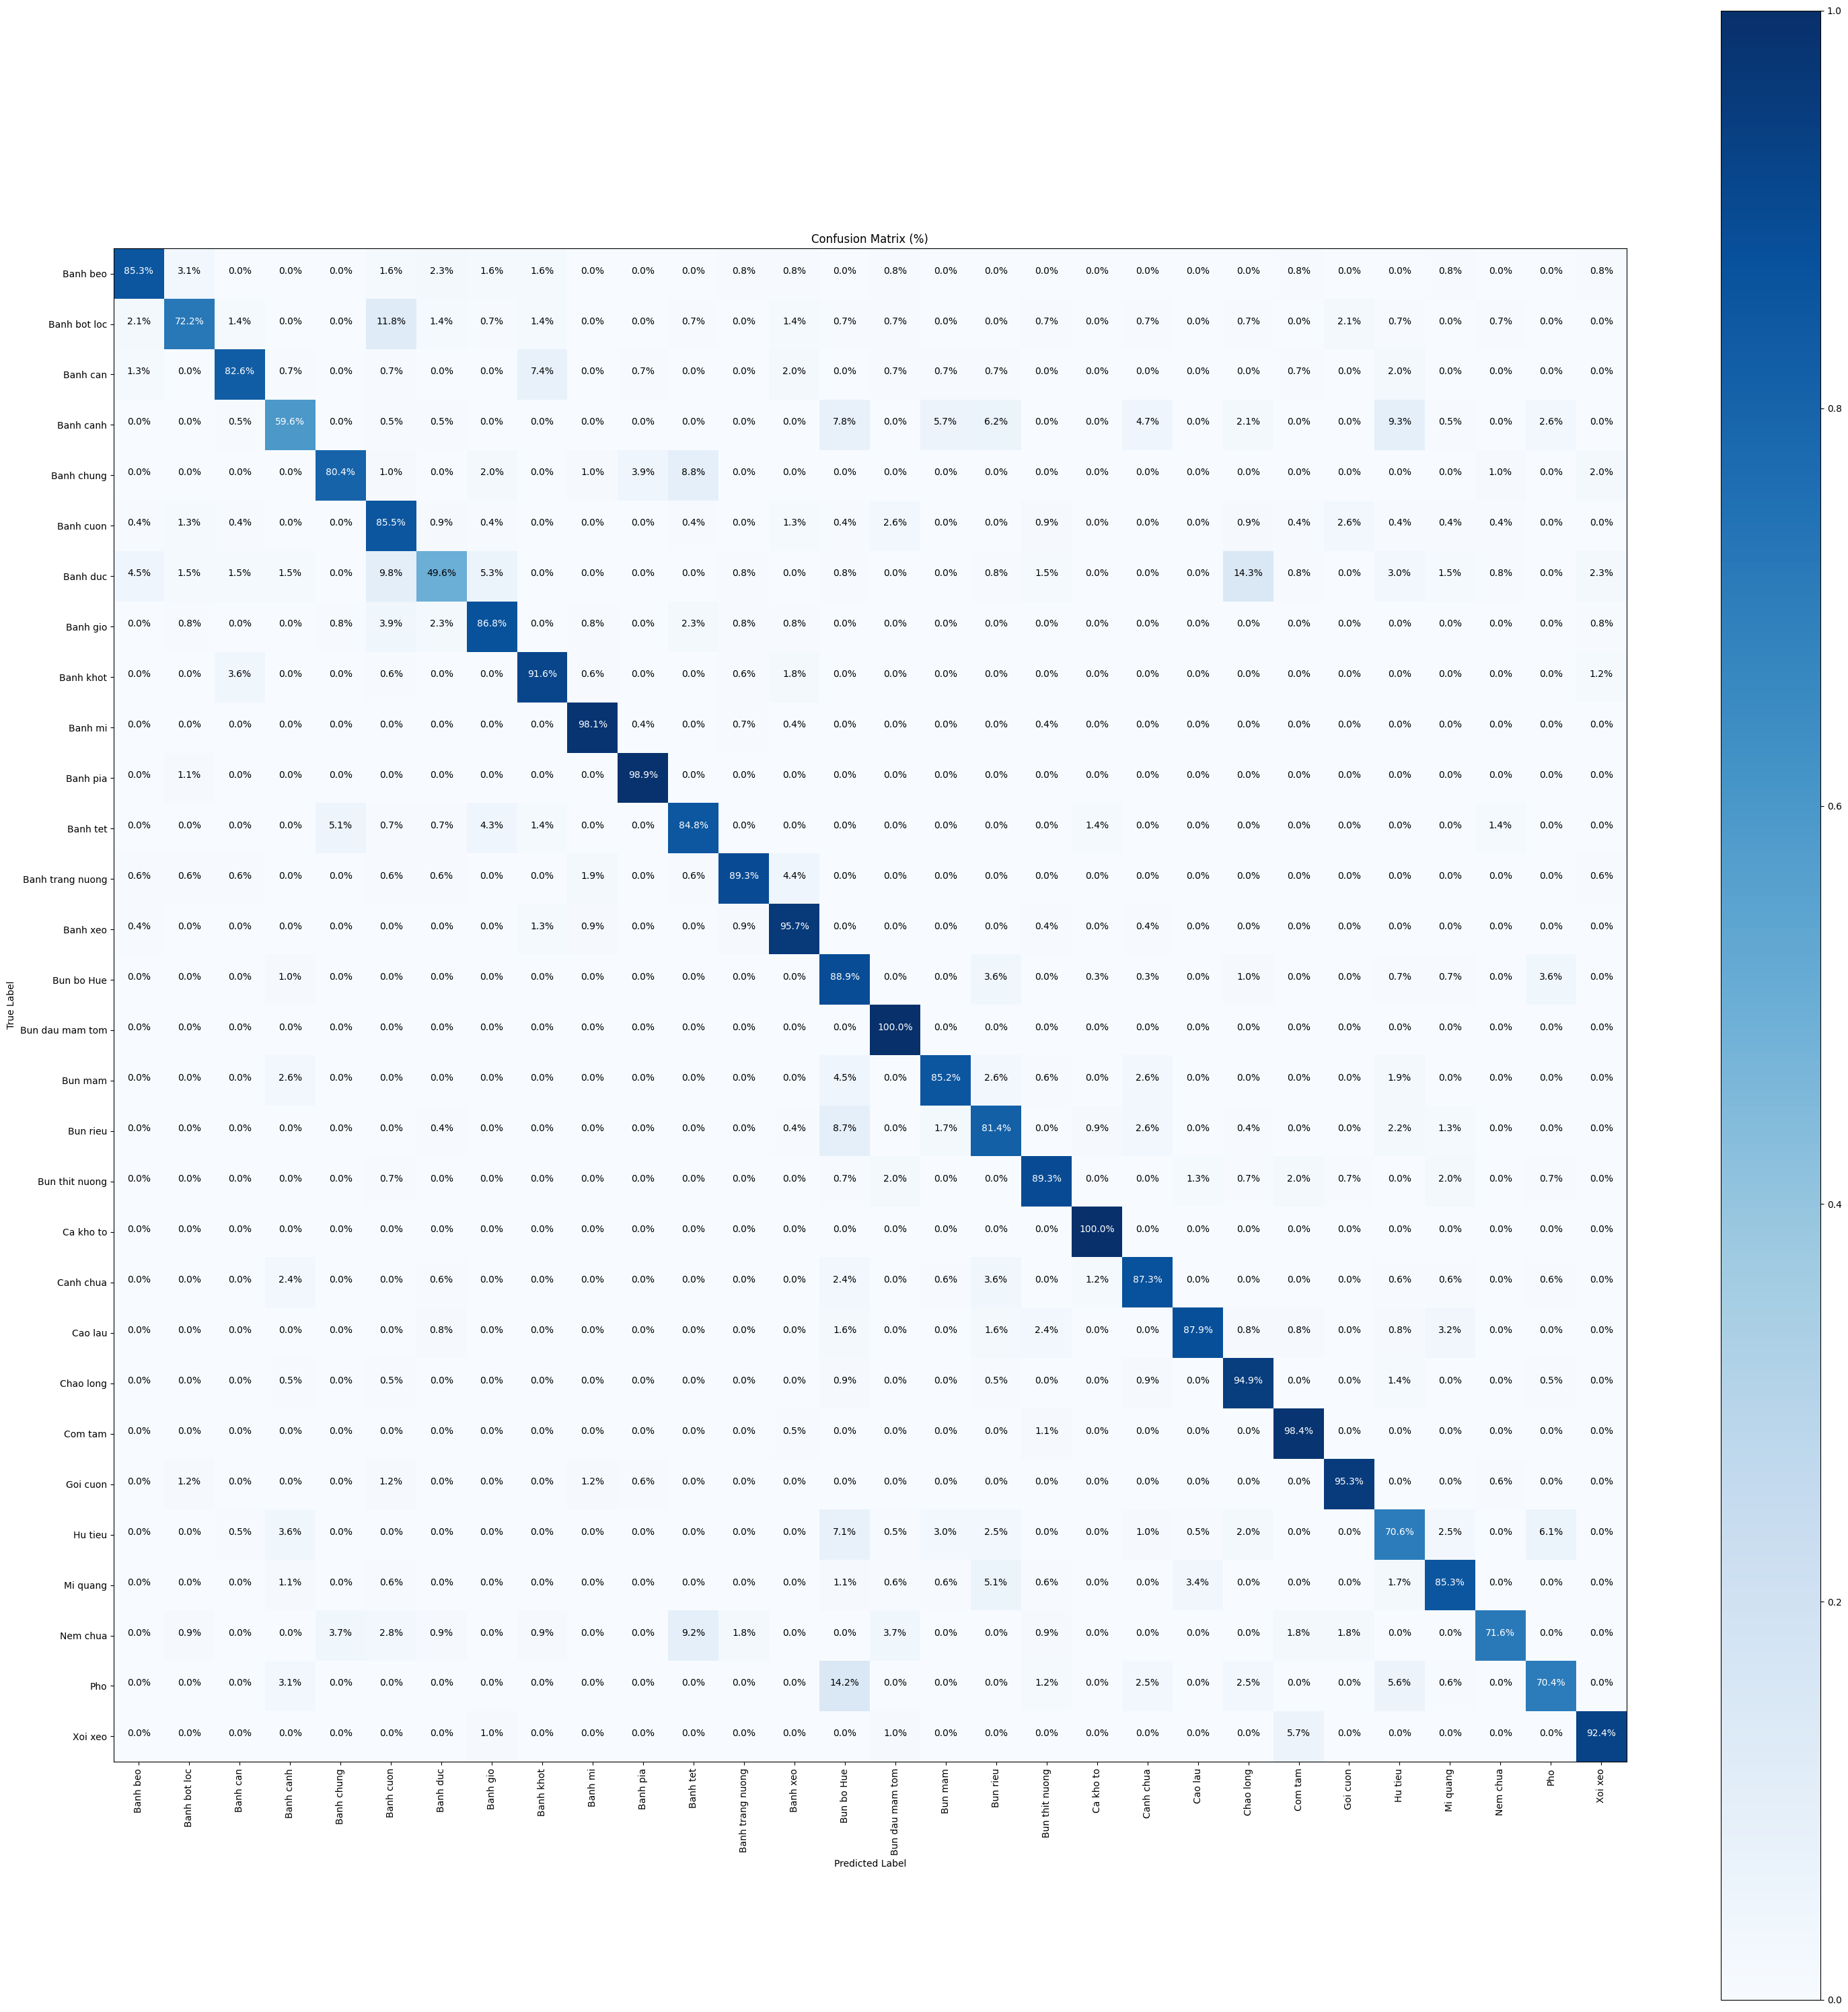

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(30, 30))
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (%)")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)

# Hiển thị số phần trăm trong từng ô
thresh = cm_percent.max() / 2
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f"{cm_percent[i, j]*100:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > thresh else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# **III. Support Vector Machine**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


In [ ]:

param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.001, 0.0001]
    }
]

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


 **Vì quá lâu nên đã dùng kaggle để chạy SVM này.**

Kết quả :

Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [ ]:
svm = SVC(
    kernel="rbf",        
    C=10,               
    gamma=0.01,       
    probability=True,    # nếu bạn muốn dùng predict_proba
    random_state=42
)


In [45]:
svm.fit(X_train, y_train)


SVC(C=10, gamma=0.01, probability=True, random_state=42)

In [46]:
y_pred = svm.predict(X_test)


In [47]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9176587301587301
                  precision    recall  f1-score   support

        Banh beo       0.94      0.91      0.92       129
    Banh bot loc       0.91      0.88      0.89       144
        Banh can       0.94      0.91      0.92       149
       Banh canh       0.81      0.83      0.82       193
      Banh chung       0.87      0.88      0.88       102
       Banh cuon       0.91      0.90      0.91       228
        Banh duc       0.79      0.87      0.83       133
        Banh gio       0.93      0.91      0.92       129
       Banh khot       0.93      0.92      0.93       167
         Banh mi       0.98      0.99      0.98       268
        Banh pia       0.97      0.99      0.98        89
        Banh tet       0.89      0.90      0.90       138
Banh trang nuong       0.94      0.94      0.94       159
        Banh xeo       0.95      0.96      0.95       235
      Bun bo Hue       0.84      0.91      0.87       306
 Bun dau mam tom       0.98      0.99     

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)



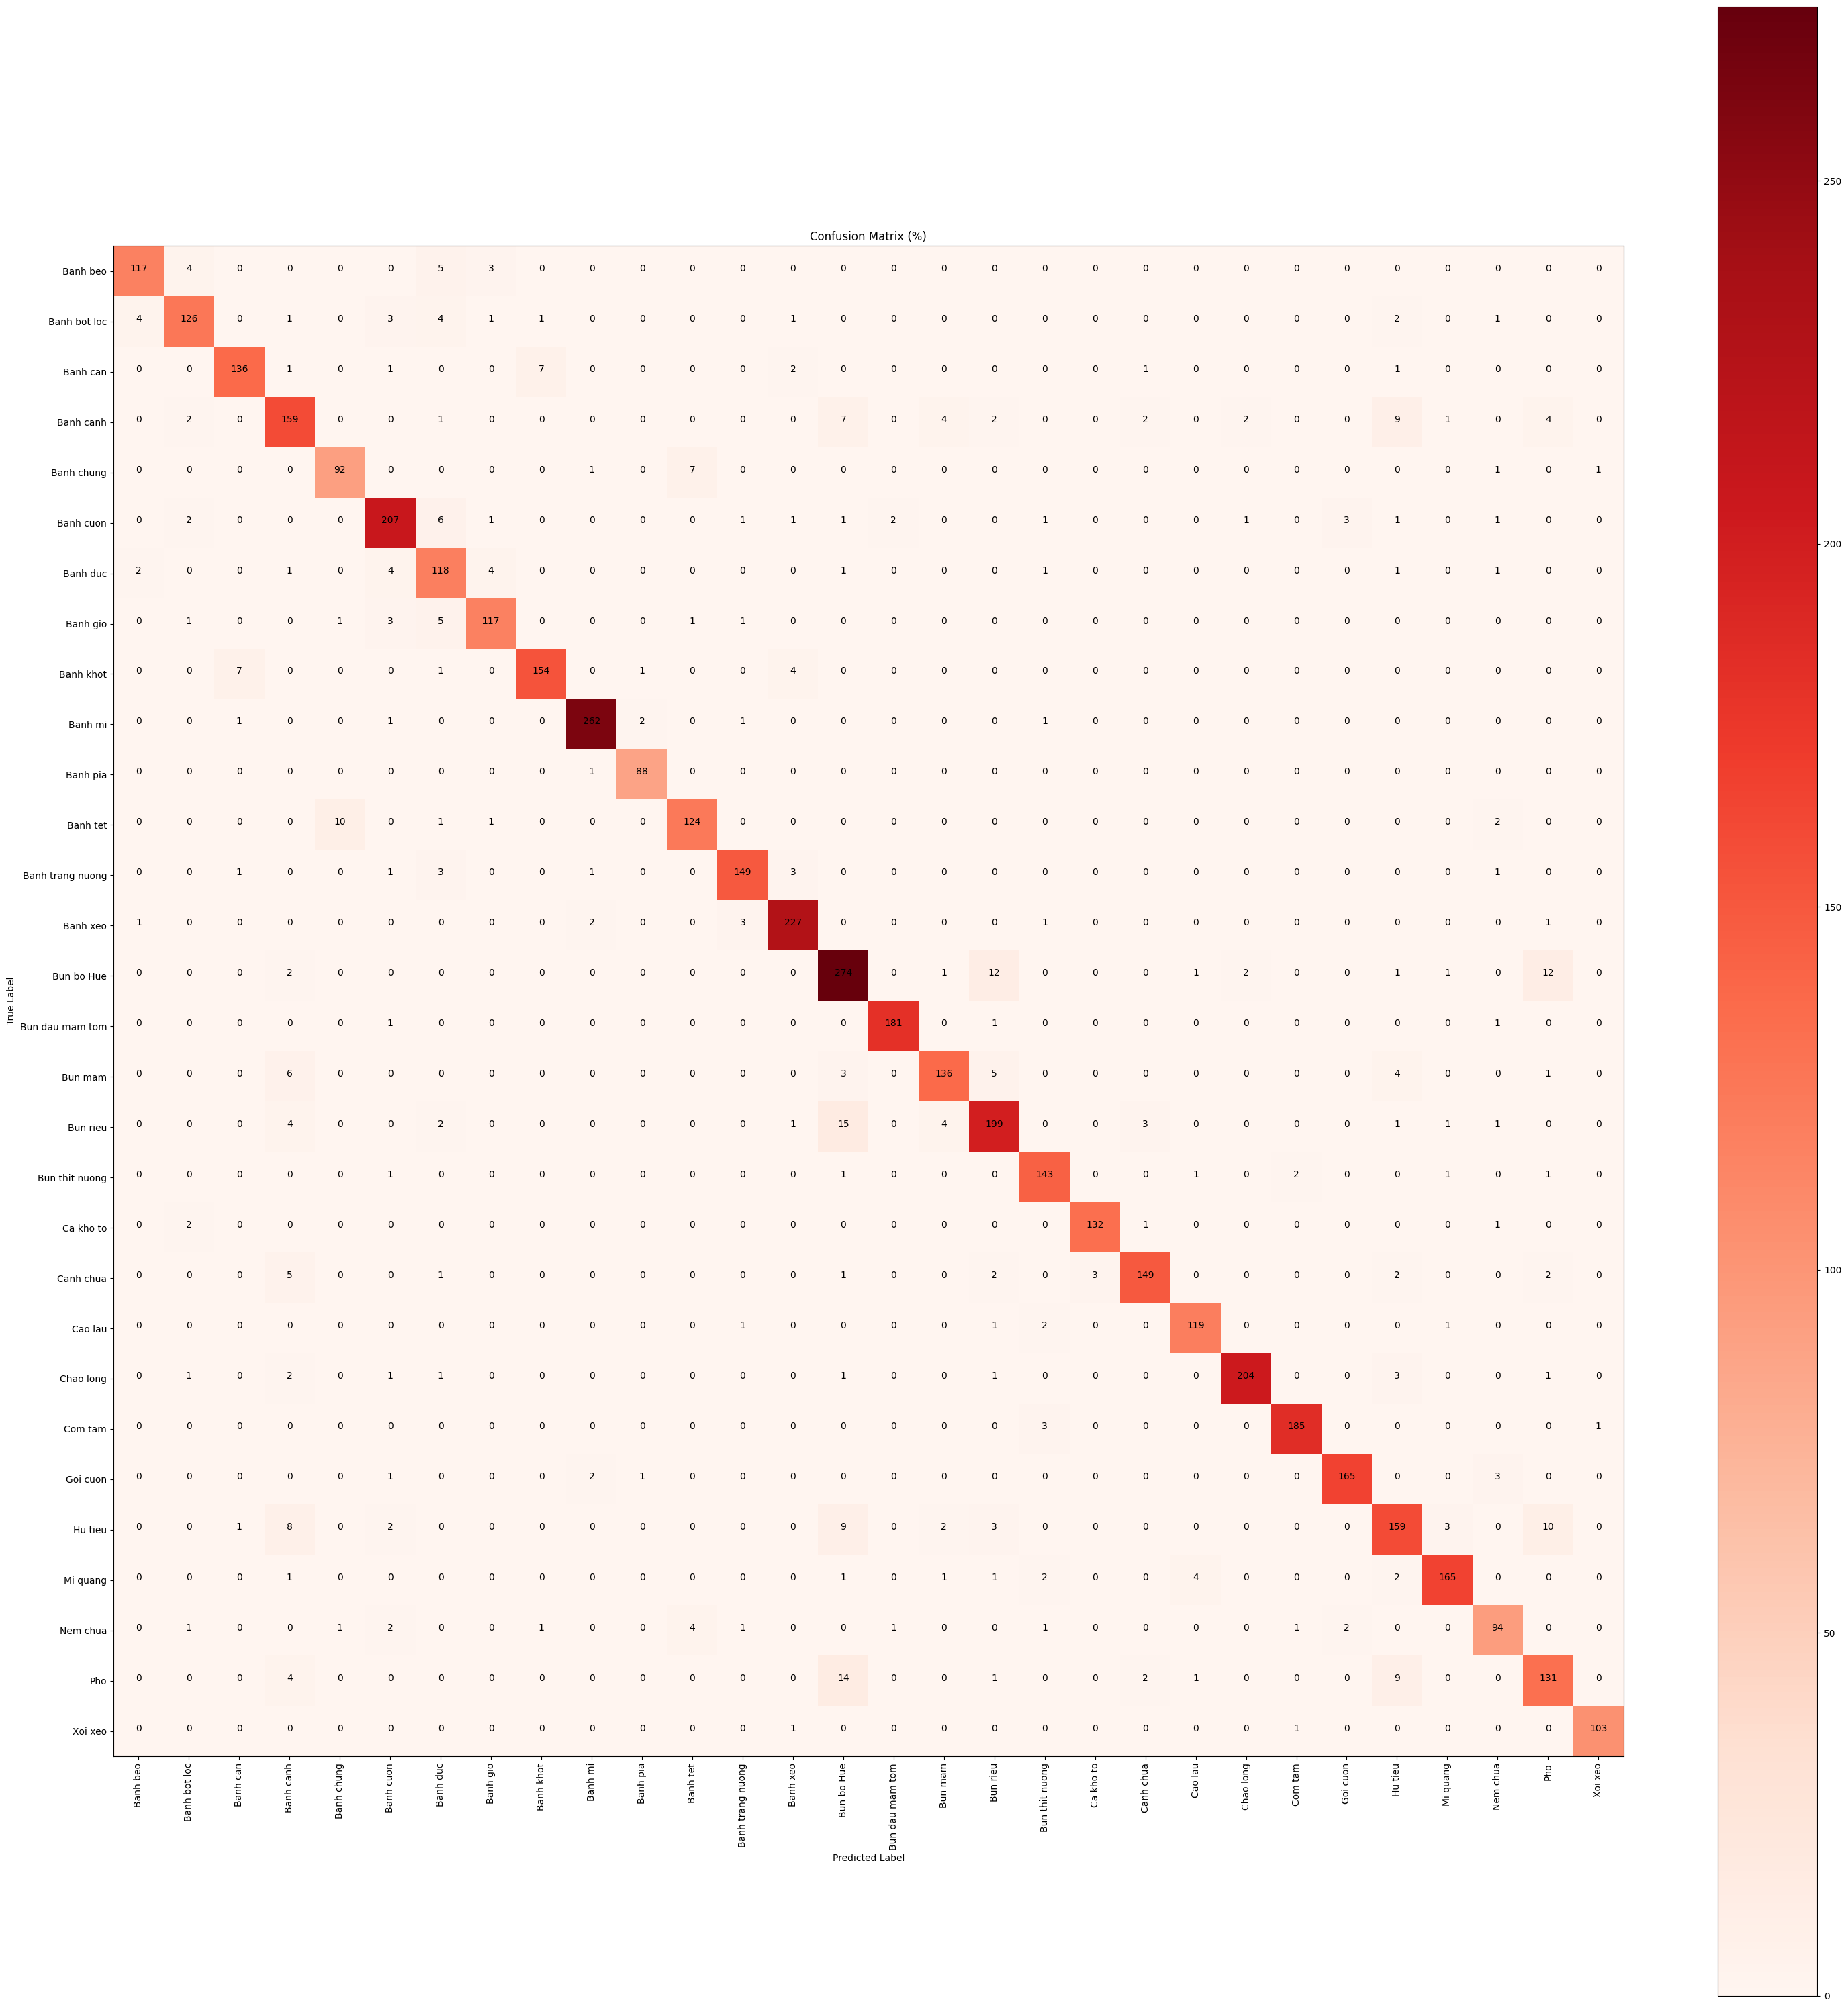

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(30, 30))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)

# Hiển thị số phần trăm trong từng ô
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]}",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > thresh else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [27]:
from sklearn.metrics import confusion_matrix

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # axis = 1 theo hàng


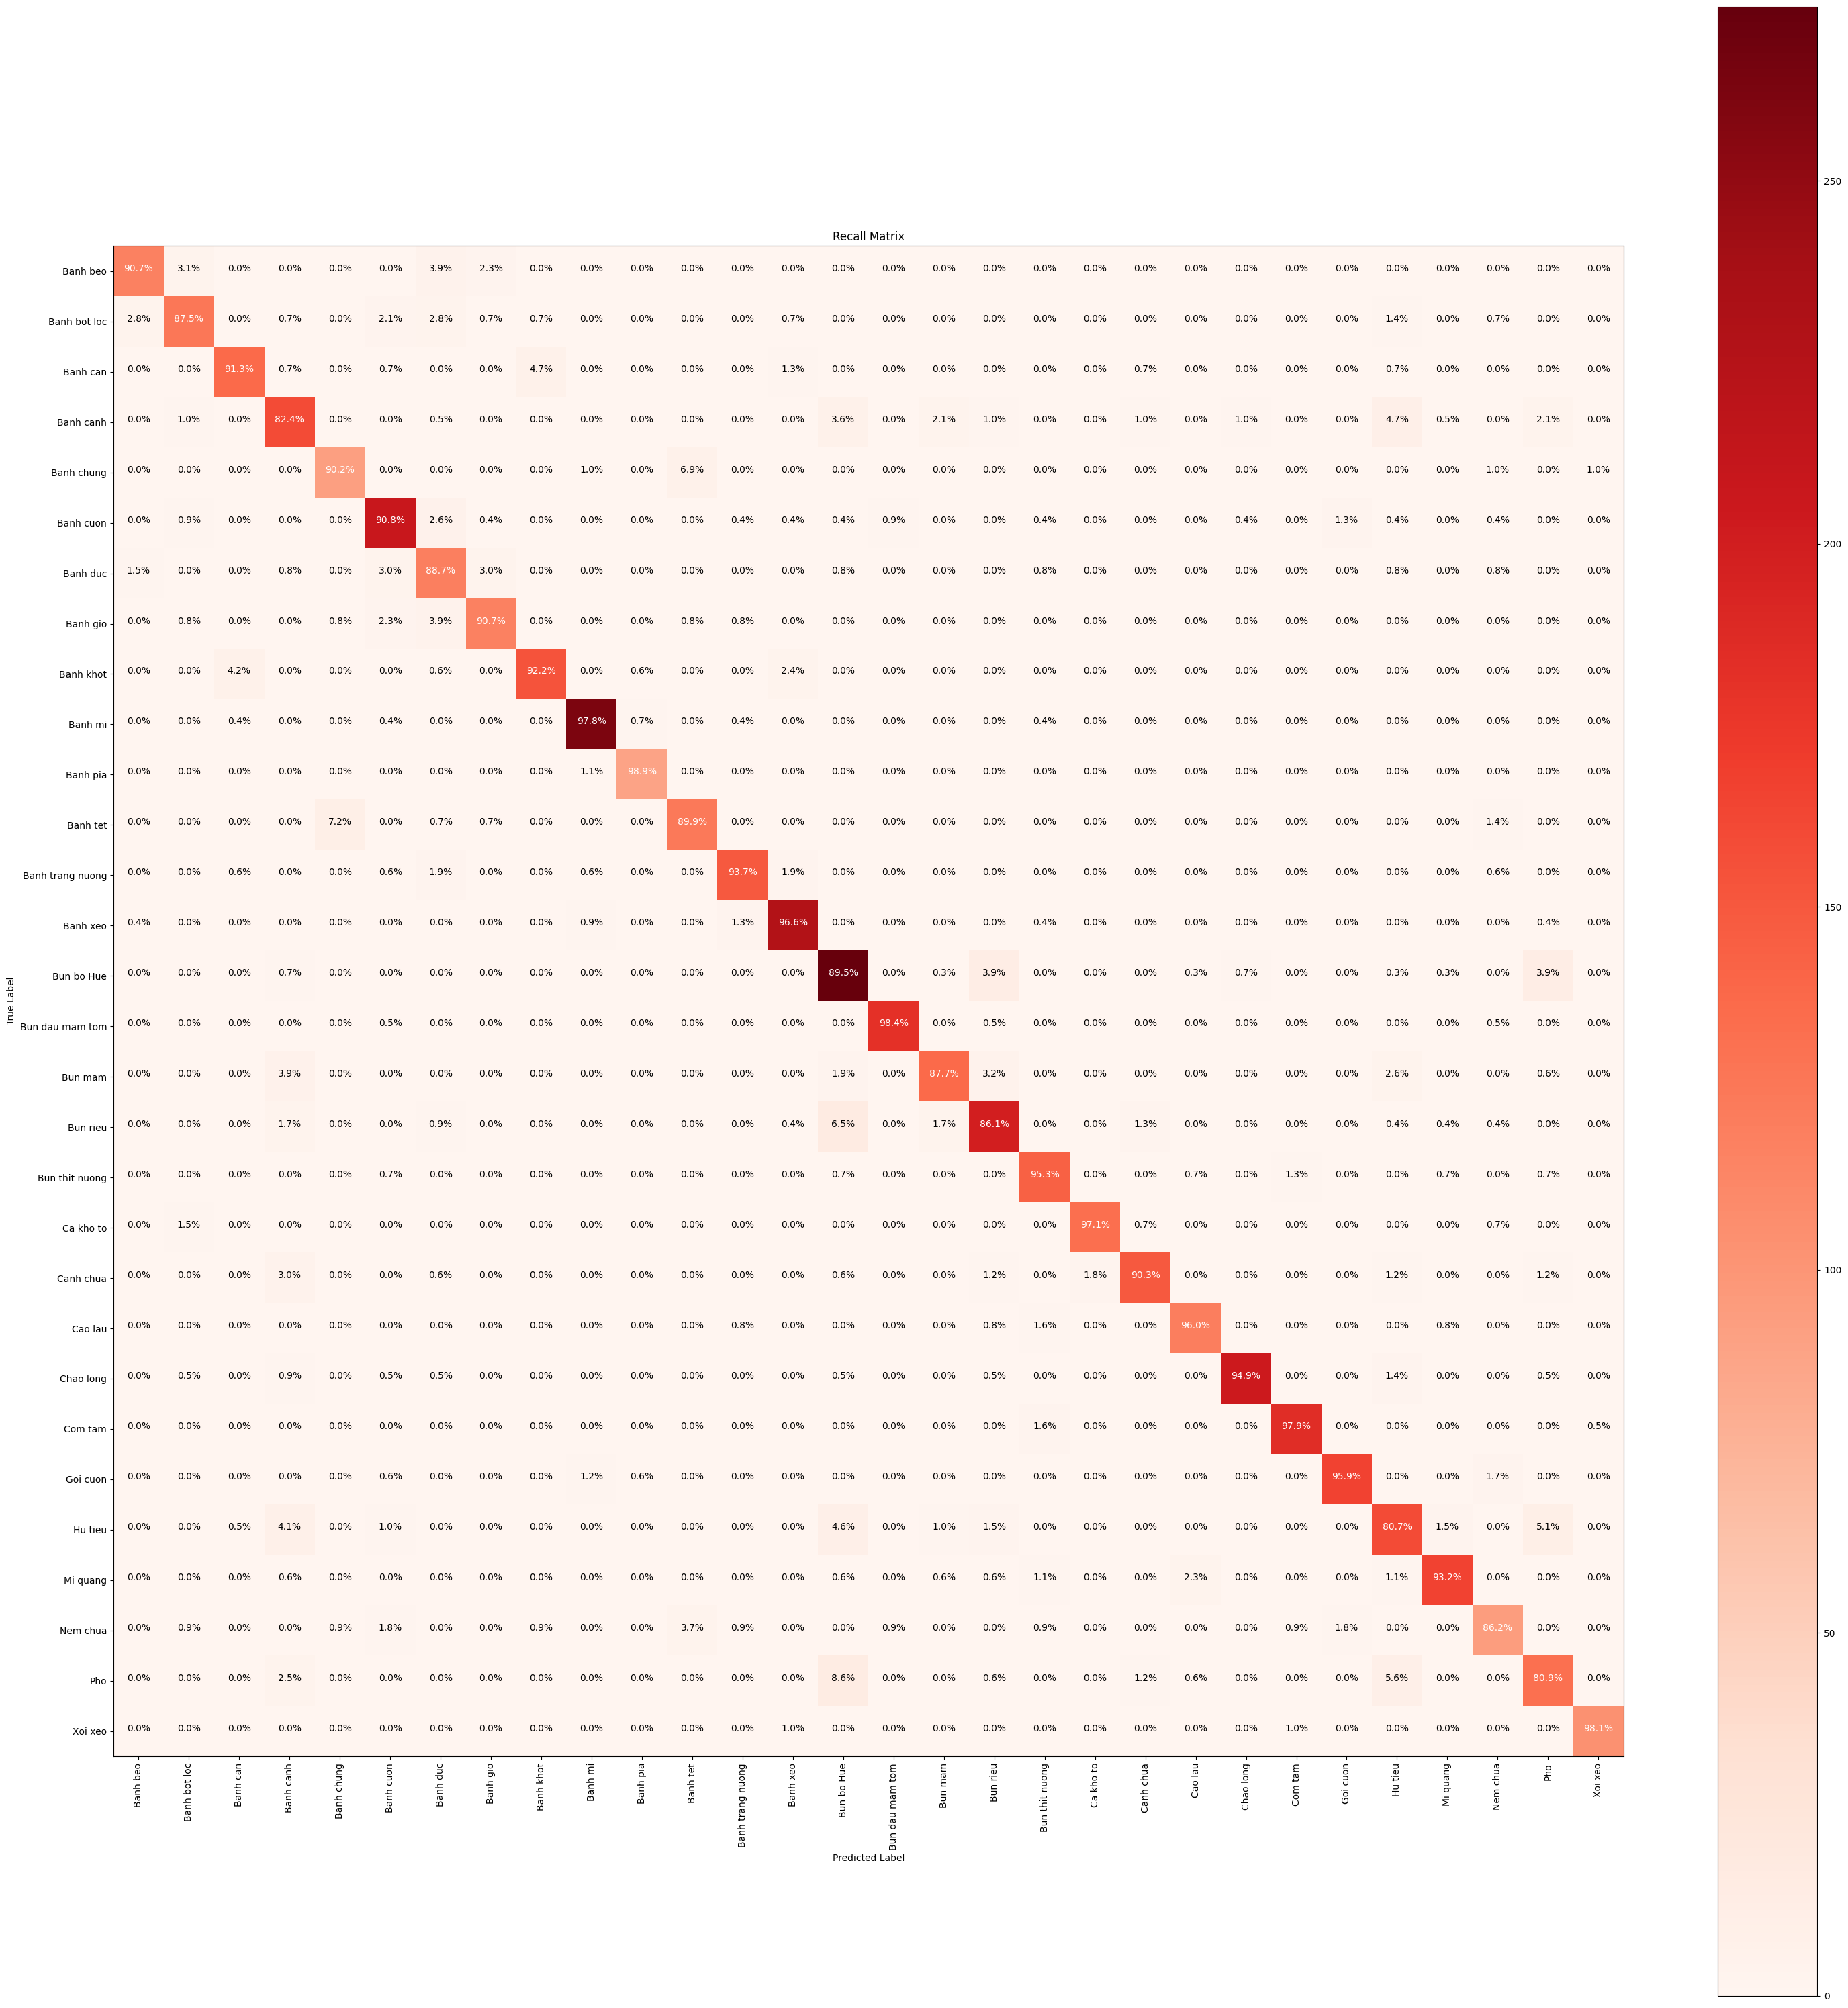

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(30, 30))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
plt.title("Recall Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)

# Hiển thị số phần trăm trong từng ô
thresh = cm_percent.max() / 2
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f"{cm_percent[i, j]*100:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > thresh else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [29]:
from sklearn.metrics import confusion_matrix

cm_percent = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis] # axis = 1 theo hàng


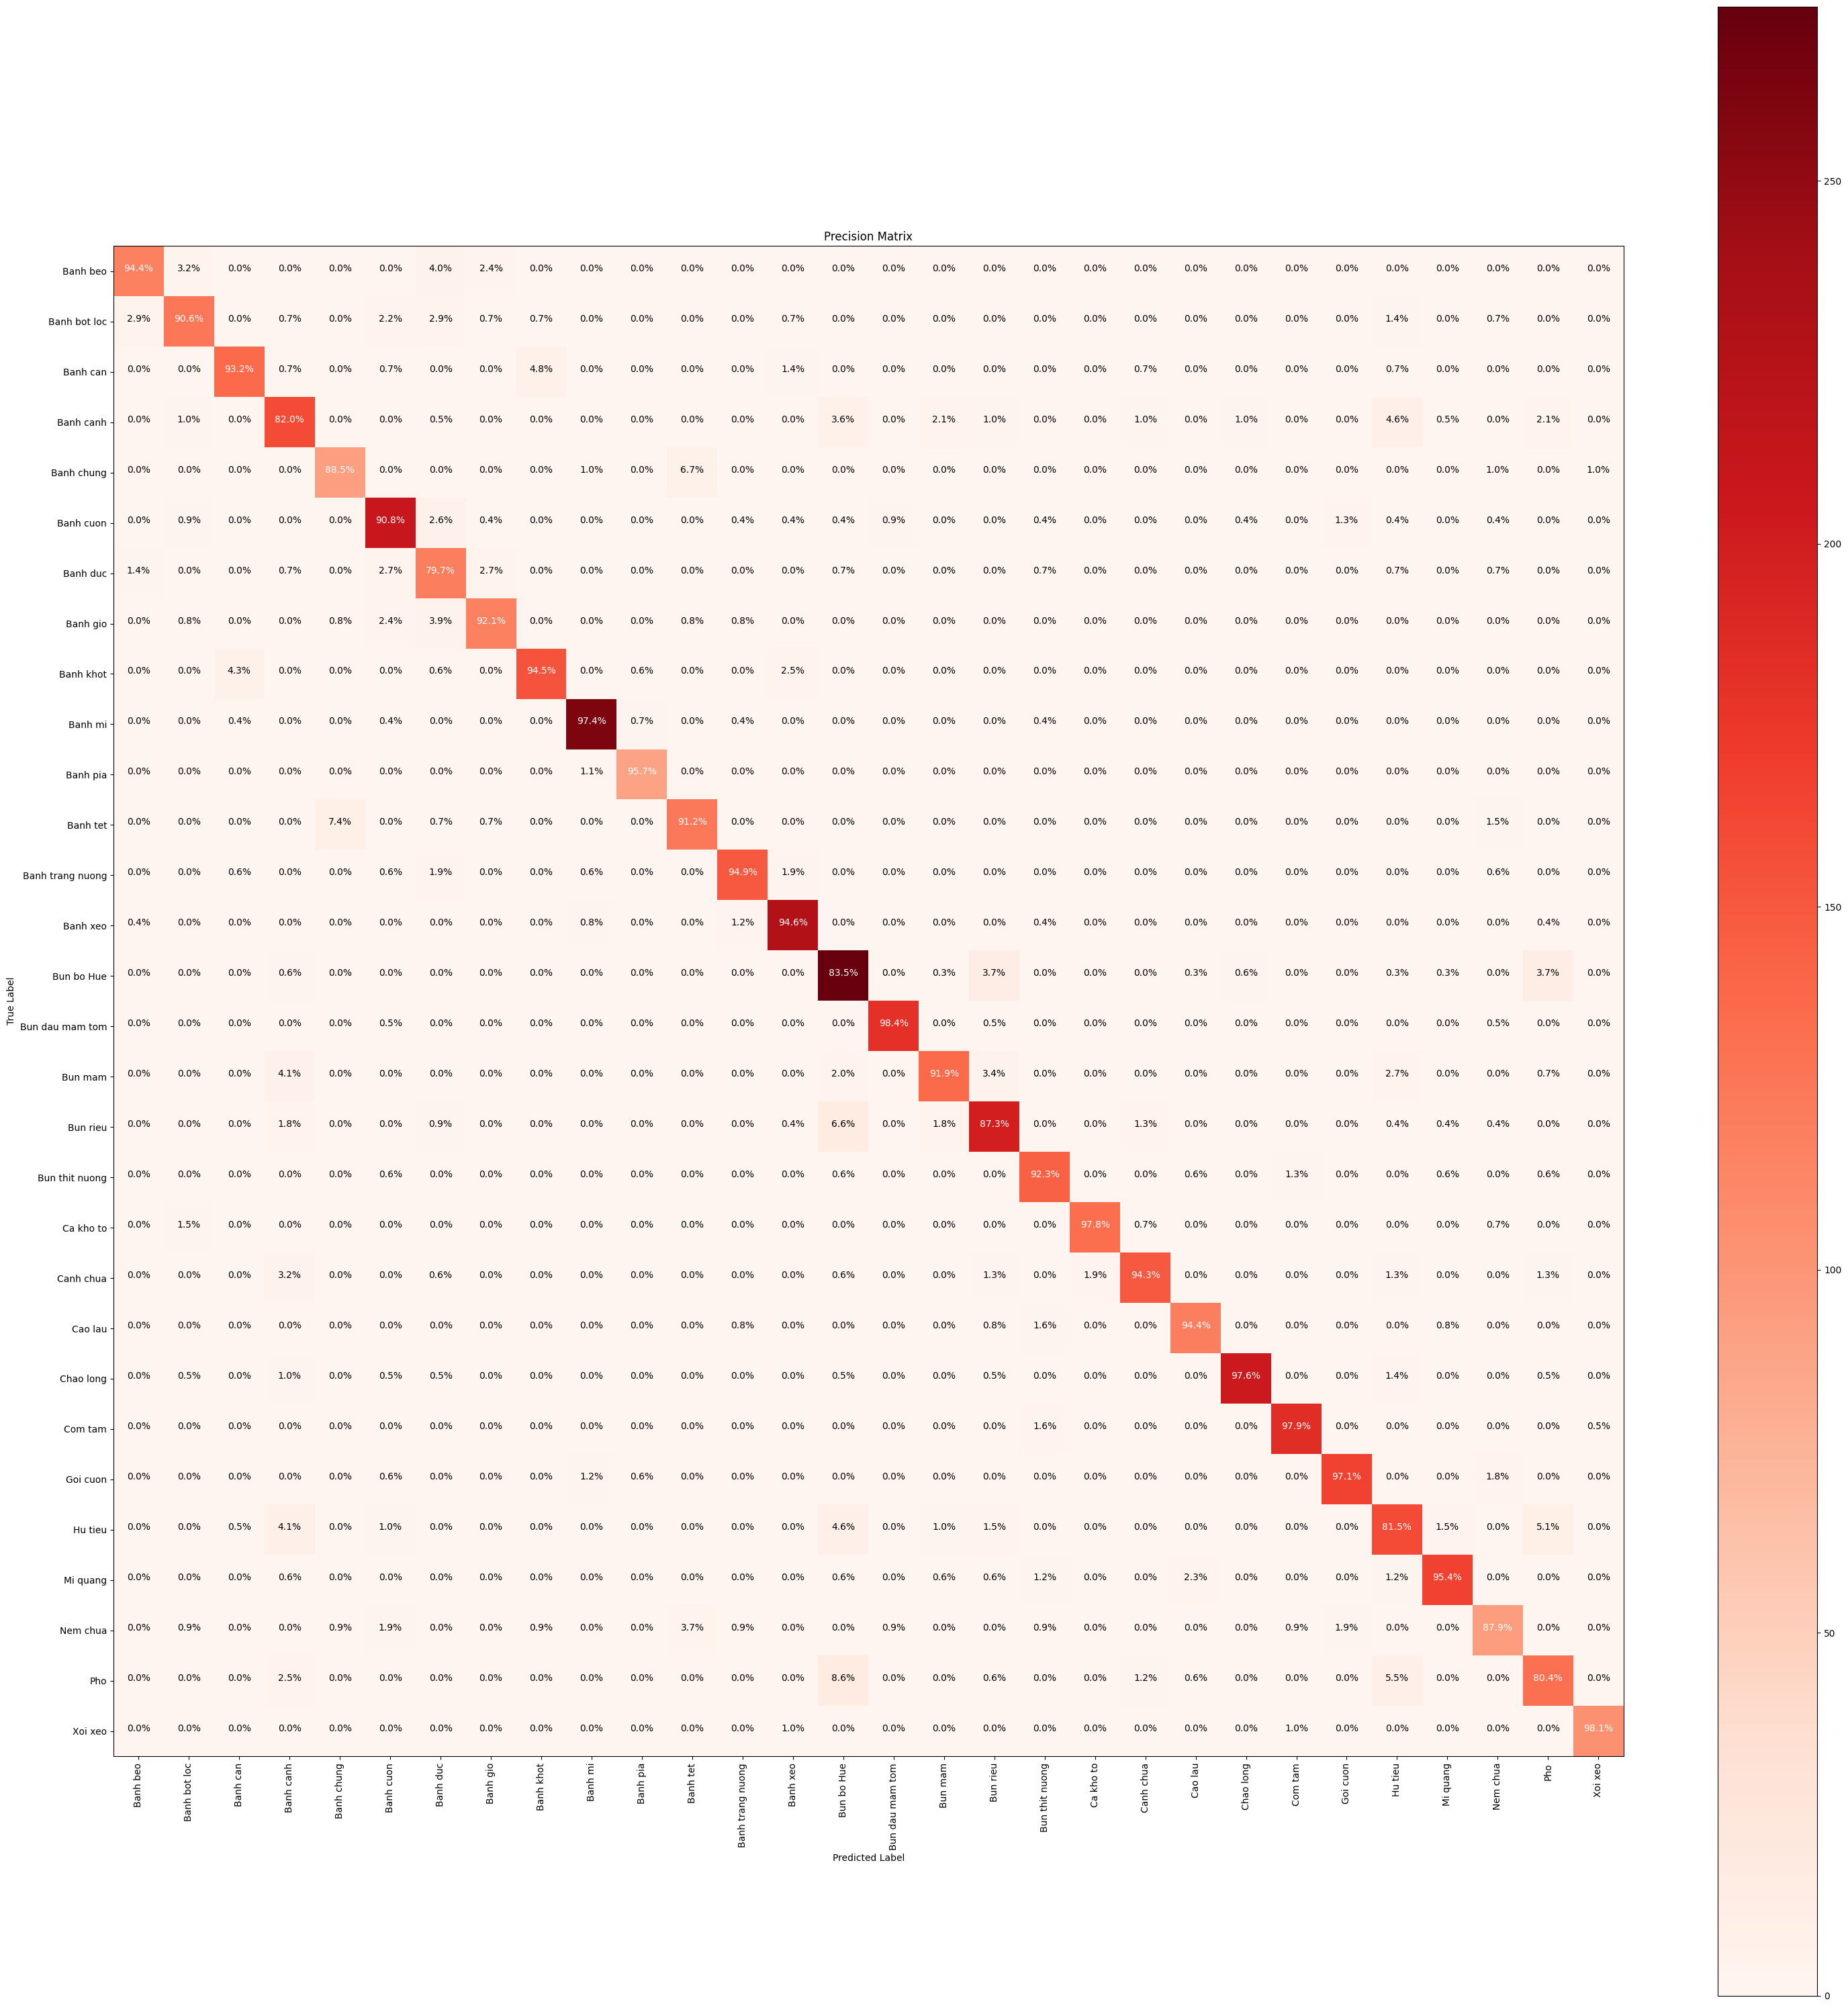

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(30, 30))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
plt.title("Precision Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)

# Hiển thị số phần trăm trong từng ô
thresh = cm_percent.max() / 2
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f"{cm_percent[i, j]*100:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > thresh else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [16]:
import joblib
filename_joblib = 'svm_for_vitl14_joblib.pkl'
joblib.dump(svm, filename_joblib)


['svm_for_vitl14_joblib.pkl']

In [17]:
svm.get_params()


{'C': 10,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 0.01,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [18]:
from sklearn.preprocessing import LabelEncoder

# Extract the classes and create a dictionary
# The classes_ attribute contains the unique labels in sorted order,
# and their index in this array corresponds to their encoded integer value.
label_mapping = {label: index for index, label in enumerate(label_encoder.classes_)}

print("Label Mapping Dictionary:")
print(label_mapping)


Label Mapping Dictionary:
{'Banh beo': 0, 'Banh bot loc': 1, 'Banh can': 2, 'Banh canh': 3, 'Banh chung': 4, 'Banh cuon': 5, 'Banh duc': 6, 'Banh gio': 7, 'Banh khot': 8, 'Banh mi': 9, 'Banh pia': 10, 'Banh tet': 11, 'Banh trang nuong': 12, 'Banh xeo': 13, 'Bun bo Hue': 14, 'Bun dau mam tom': 15, 'Bun mam': 16, 'Bun rieu': 17, 'Bun thit nuong': 18, 'Ca kho to': 19, 'Canh chua': 20, 'Cao lau': 21, 'Chao long': 22, 'Com tam': 23, 'Goi cuon': 24, 'Hu tieu': 25, 'Mi quang': 26, 'Nem chua': 27, 'Pho': 28, 'Xoi xeo': 29}


In [24]:
np.array(np.load('ViT-L14-embeddings-vectors/Train/Banh beo/1.npy')).shape


(768,)

# IV. **Load the best model and evaluate on the test set**

In [ ]:
import joblib


In [11]:
svm = joblib.load('../30VNFoods/models/svm_for_vitl14_joblib.pkl')


In [12]:
y_pred = svm.predict(X_test)


In [14]:
mismatched_indices = np.where(y_pred != y_test)[0]
mismatched_data = X_test[mismatched_indices]
mismatched_labels = y_test[mismatched_indices]
predicted_labels = y_pred[mismatched_indices]

for i, idx in enumerate(mismatched_indices):
    print(f"Index: {idx}, True Label: {mismatched_labels[i]}, Predicted Label: {predicted_labels[i]}")


Index: 1, True Label: 7, Predicted Label: 6
Index: 7, True Label: 7, Predicted Label: 6
Index: 10, True Label: 7, Predicted Label: 5
Index: 27, True Label: 7, Predicted Label: 6
Index: 33, True Label: 7, Predicted Label: 6
Index: 41, True Label: 7, Predicted Label: 5
Index: 68, True Label: 7, Predicted Label: 4
Index: 76, True Label: 7, Predicted Label: 5
Index: 103, True Label: 7, Predicted Label: 12
Index: 120, True Label: 7, Predicted Label: 11
Index: 123, True Label: 7, Predicted Label: 6
Index: 128, True Label: 7, Predicted Label: 1
Index: 146, True Label: 20, Predicted Label: 25
Index: 162, True Label: 20, Predicted Label: 19
Index: 178, True Label: 20, Predicted Label: 3
Index: 179, True Label: 20, Predicted Label: 19
Index: 182, True Label: 20, Predicted Label: 3
Index: 190, True Label: 20, Predicted Label: 19
Index: 196, True Label: 20, Predicted Label: 3
Index: 200, True Label: 20, Predicted Label: 3
Index: 207, True Label: 20, Predicted Label: 25
Index: 209, True Label: 20, 